# Merged Tooltips

When several data points are hit at the same cursor location, Lets-Plot shows a general tooltip for each target. Two `theme()` parameters control how these are displayed:

- `tooltip_merge` — if `True`, the per-target tooltips are combined into a single merged tooltip.
- `tooltip_max_count` — a guard against clutter: if the number of targets at a location exceeds it (default `10`), only the closest target is shown. Set to `0` to disable the limit.

> These effects are interactive: hover the cursor over the lines near a shared `x` to see the tooltips.


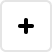
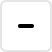
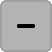
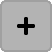
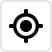
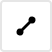
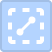
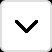
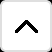
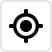
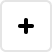
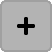
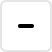
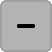
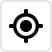
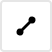
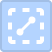
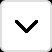
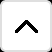
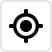

In [1]:
import numpy as np
import pandas as pd
from lets_plot import *

LetsPlot.setup_html()

In [2]:
n_series = 12
months = list(range(1, 13))

np.random.seed(42)
records = []
for s in range(n_series):
    base = np.random.uniform(10, 40)
    trend = np.random.uniform(-1.5, 1.5)
    for m in months:
        value = base + trend * m + np.random.normal(0, 1.5)
        records.append({'month': m, 'value': round(value, 1), 'series': f'series {s + 1:02d}'})

df = pd.DataFrame(records)
df.head(3)

,month,value,series
0,1,23.6,series 01
1,2,26.2,series 01
2,3,24.9,series 01


In [3]:
base_plot = (
    ggplot(df, aes('month', 'value', color='series')) +
    geom_line(size=1, tooltips=layer_tooltips().line('@series: @value')) +
    ggsize(700, 400)
)

## Default Behavior

There are 12 series, so hovering near an `x` hits more targets than the default `tooltip_max_count` (`10`). When the limit is exceeded, Lets-Plot keeps the clutter down by showing only the **closest** target.

In [4]:
base_plot

## Merging: `tooltip_merge=True`

`tooltip_merge=True` combines the per-target tooltips into a single box — one row per series, each with its color marker — a much cleaner way to show them all at once.

All 12 series appear even though that exceeds the default `tooltip_max_count` of `10`: merging takes priority over the limit, so `tooltip_max_count` is ignored and every target is collected into the merged tooltip.

In [5]:
base_plot + theme(tooltip_merge=True)

## Stacked Bars

Merging is just as useful for stacked bars: hovering over a bar hits every segment in the stack, so a merged tooltip summarizes the whole stack in a single box.

In [6]:
np.random.seed(1)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
products = [f'product {i + 1}' for i in range(5)]
bar_records = [
    {'quarter': q, 'product': p, 'sales': int(np.random.randint(5, 30))}
    for q in quarters
    for p in products
]
bars_df = pd.DataFrame(bar_records)
bars_df.head(3)

,quarter,product,sales
0,Q1,product 1,10
1,Q1,product 2,16
2,Q1,product 3,17


In [7]:
(ggplot(bars_df, aes('quarter', 'sales', fill='product')) +
    geom_bar(stat='identity', tooltips=layer_tooltips().line('@product: @sales')) +
    ggsize(700, 400) +
    theme(tooltip_merge=True))

## Side Tooltips: `geom_errorbar` with `disable_splitting()`

By default, geoms like `geom_errorbar` *split* their tooltip: the general tooltip is broken into a general
tooltip plus a set of *side* tooltips (here, the interval bounds) placed next to the data.
`layer_tooltips().disable_splitting()` turns splitting off, rebuilding a single general tooltip —
which merging can then combine across the group at a category into one box.

In [8]:
np.random.seed(2)
err_rows = []
for c in ['A', 'B', 'C', 'D']:
    for g in ['group 1', 'group 2', 'group 3']:
        m = np.random.uniform(8, 18)
        e = np.random.uniform(1.5, 3.5)
        err_rows.append({'category': c, 'group': g, 'mean': round(m, 1),
                         'ymin': round(m - e, 1), 'ymax': round(m + e, 1)})
err_df = pd.DataFrame(err_rows)

(ggplot(err_df, aes('category', 'mean', color='group')) +
    geom_errorbar(aes(ymin='ymin', ymax='ymax'), size=1,
                  tooltips=layer_tooltips().title('@group').disable_splitting()) +
    ggsize(700, 400) +
    theme(tooltip_merge=True))